https://365datascience.com/tutorials/python-tutorials/pca-k-means/

In [1]:
# Load general libraries
import numpy as np
import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objs as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

import umap

2024-09-17 08:28:46.181517: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-09-17 08:28:46.181554: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## Data load

In [2]:
nuclei = pd.read_csv('/app/data/cellprofiler_segmentation/watershed_nuclei.txt', sep='\t', index_col = 1)
membrane = pd.read_csv('/app/data/cellprofiler_segmentation/object_membrane.txt', sep='\t', index_col = 1)
cytoplasm = pd.read_csv('/app/data/cellprofiler_segmentation/filtered_segmented_cytoplasm.txt', sep='\t', index_col = 1)

In [3]:
col = nuclei.pop('Children_filtered_segmented_cytoplasm_Count')
nuclei.insert(0, 'Children_filtered_segmented_cytoplasm_Count', col)
display(nuclei)

,Children_filtered_segmented_cytoplasm_Count,ImageNumber,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMaximum_Z,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_BoundingBoxMinimum_Z,AreaShape_BoundingBoxVolume,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_Center_Z,AreaShape_EquivalentDiameter,AreaShape_EulerNumber,AreaShape_Extent,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_SurfaceArea,AreaShape_Volume,Location_Center_X,Location_Center_Y,Location_Center_Z,Number_Object_Number
ObjectNumber,,,,,,,,,,,,,,,,,,,,,,,
1,1,1,174,16,4,146,0,0,1792,157.801205,4.971888,0.554217,9.834303,0,0.277902,28.236047,14.801025,378.552704,498,157.801205,4.971888,0.554217,1
2,1,1,208,43,10,174,0,0,14620,192.135186,18.481298,4.224152,24.270780,0,0.512038,49.625393,26.442739,1480.238281,7486,192.135186,18.481298,4.224152,2
3,4,1,61,59,10,0,7,0,31720,26.715728,31.620971,2.639391,22.092630,-1,0.177995,82.046252,35.357546,3068.510742,5646,26.715728,31.620971,2.639391,3
4,1,1,90,84,8,69,64,0,3360,78.995565,74.631929,3.494457,9.514646,1,0.134226,24.445469,13.891595,651.103027,451,78.995565,74.631929,3.494457,4
5,1,1,200,108,3,182,86,0,1188,191.513725,97.454902,0.605882,9.912667,1,0.429293,24.723139,15.361054,390.437103,510,191.513725,97.454902,0.605882,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,1,1,1405,1898,10,1402,1895,9,9,1402.833333,1895.833333,9.000000,2.254503,1,0.666667,3.887301,2.309401,13.988679,6,1402.833333,1895.833333,9.000000,472
473,0,1,1221,2450,10,1218,2447,9,9,1218.666667,2448.333333,9.000000,2.254503,1,0.666667,4.216370,2.108185,14.585056,6,1218.666667,2448.333333,9.000000,473
474,1,1,1515,2476,10,1512,2474,9,6,1513.200000,2474.400000,9.000000,2.121569,1,0.833333,3.577709,1.788854,12.353006,5,1513.200000,2474.400000,9.000000,474


In [4]:
col = cytoplasm.pop('Parent_watershed_nuclei')
cytoplasm.insert(0, 'Parent_watershed_nuclei', col)
display(cytoplasm)

,Parent_watershed_nuclei,ImageNumber,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMaximum_Z,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_BoundingBoxMinimum_Z,AreaShape_BoundingBoxVolume,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_Center_Z,AreaShape_EquivalentDiameter,AreaShape_EulerNumber,AreaShape_Extent,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_SurfaceArea,AreaShape_Volume,Location_Center_X,Location_Center_Y,Location_Center_Z,Number_Object_Number,Parent_segmented_cytoplasm
ObjectNumber,,,,,,,,,,,,,,,,,,,,,,,,
1,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
2,3,1,68,39,10,23,0,0,17550,45.546510,16.311951,4.372377,23.411829,0,0.382849,53.048634,28.615474,1606.489502,6719,45.546510,16.311951,4.372377,2,2
3,312,1,80,18,10,51,0,0,5220,64.303183,5.867948,4.318311,18.231559,1,0.607854,32.457302,19.753127,578.871826,3173,64.303183,5.867948,4.318311,3,3
4,3,1,212,118,10,31,0,0,213580,123.923083,49.438160,4.473402,54.322718,0,0.392991,173.872360,91.988569,10275.375000,83935,123.923083,49.438160,4.473402,4,4
5,1,1,171,21,10,129,0,0,8820,152.524819,5.739042,4.542525,18.738301,1,0.390590,38.710415,20.184015,722.996399,3445,152.524819,5.739042,4.542525,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,300,1,97,3788,10,20,3658,0,100100,54.077991,3722.068483,4.513160,50.099409,1,0.657752,150.772369,70.163543,3698.781738,65841,54.077991,3722.068483,4.513160,1273,1338
1274,0,1,20,3724,10,0,3667,0,11400,9.289546,3696.008028,4.511221,27.561132,1,0.961579,67.597131,25.510094,847.698120,10962,9.289546,3696.008028,4.511221,1274,1339
1275,0,1,183,3788,10,65,3685,0,121540,121.394864,3742.009217,4.527759,53.062294,0,0.643632,145.306010,101.361366,3704.875732,78227,121.394864,3742.009217,4.527759,1275,1340


In [5]:
nuclei_cytoplasm = pd.merge(nuclei, cytoplasm, left_on = 'Children_filtered_segmented_cytoplasm_Count', right_on = 'ObjectNumber', suffixes = ('_nuclei', '_cytoplasm'))
nuclei_cytoplasm = nuclei_cytoplasm.drop(columns=['Children_filtered_segmented_cytoplasm_Count', 'Parent_segmented_cytoplasm', 'Parent_watershed_nuclei', 'ImageNumber_nuclei', 'Number_Object_Number_nuclei', 'ImageNumber_cytoplasm', 'Number_Object_Number_cytoplasm'])

In [6]:
display(nuclei_cytoplasm)

,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMaximum_Z_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_BoundingBoxMinimum_Z_nuclei,AreaShape_BoundingBoxVolume_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Center_Z_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,Location_Center_X_nuclei,Location_Center_Y_nuclei,Location_Center_Z_nuclei,AreaShape_BoundingBoxMaximum_X_cytoplasm,AreaShape_BoundingBoxMaximum_Y_cytoplasm,AreaShape_BoundingBoxMaximum_Z_cytoplasm,AreaShape_BoundingBoxMinimum_X_cytoplasm,AreaShape_BoundingBoxMinimum_Y_cytoplasm,AreaShape_BoundingBoxMinimum_Z_cytoplasm,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_Center_X_cytoplasm,AreaShape_Center_Y_cytoplasm,AreaShape_Center_Z_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm,Location_Center_X_cytoplasm,Location_Center_Y_cytoplasm,Location_Center_Z_cytoplasm
0,174,16,4,146,0,0,1792,157.801205,4.971888,0.554217,9.834303,0,0.277902,28.236047,14.801025,378.552704,498,157.801205,4.971888,0.554217,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482
1,208,43,10,174,0,0,14620,192.135186,18.481298,4.224152,24.270780,0,0.512038,49.625393,26.442739,1480.238281,7486,192.135186,18.481298,4.224152,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482
2,90,84,8,69,64,0,3360,78.995565,74.631929,3.494457,9.514646,1,0.134226,24.445469,13.891595,651.103027,451,78.995565,74.631929,3.494457,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482
3,200,108,3,182,86,0,1188,191.513725,97.454902,0.605882,9.912667,1,0.429293,24.723139,15.361054,390.437103,510,191.513725,97.454902,0.605882,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482
4,1453,419,10,1419,381,0,12920,1436.642549,399.184755,5.278398,23.409506,1,0.519892,46.726937,32.016631,1963.811646,6717,1436.642549,399.184755,5.278398,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,3582,2214,10,3561,2195,8,798,3570.346821,2203.872832,8.809249,8.710154,-1,0.433584,27.627781,17.376481,380.693848,346,3570.346821,2203.872832,8.809249,80,18,10,51,0,0,5220,64.303183,5.867948,4.318311,18.231559,1,0.607854,32.457302,19.753127,578.871826,3173,64.303183,5.867948,4.318311
378,3573,1031,10,3511,949,0,50840,3544.326224,982.985765,3.698153,34.232173,1,0.413139,88.398997,49.418769,4635.945312,21004,3544.326224,982.985765,3.698153,40,60,10,0,26,0,13600,19.019857,46.880113,4.119887,23.387412,0,0.492500,49.696019,27.783340,1424.442871,6698,19.019857,46.880113,4.119887
379,2109,1054,10,2066,995,0,25370,2082.418143,1030.356255,5.165829,24.352638,-5,0.298069,57.294631,34.660827,2514.415039,7562,2082.418143,1030.356255,5.165829,171,21,10,129,0,0,8820,152.524819,5.739042,4.542525,18.738301,1,0.390590,38.710415,20.184015,722.996399,3445,152.524819,5.739042,4.542525
380,3722,2053,10,3664,2011,0,24360,3692.738225,2030.559783,4.177763,25.646030,1,0.362562,63.824693,32.020387,2357.136230,8832,3692.738225,2030.559783,4.177763,171,21,10,129,0,0,8820,152.524819,5.739042,4.542525,18.738301,1,0.390590,38.710415,20.18401

## Standarization

In [7]:
scaler = StandardScaler()
nuclei_cytoplasm_std = scaler.fit_transform(nuclei_cytoplasm)

## PCA

In [8]:
pca = PCA()
pca.fit(nuclei_cytoplasm_std)

PCA()

In [9]:
pca.explained_variance_ratio_

array([2.93972592e-01, 1.79168251e-01, 1.15387859e-01, 1.06005166e-01,
       8.95738463e-02, 8.03689100e-02, 4.20970903e-02, 3.19293329e-02,
       2.53704675e-02, 1.85410292e-02, 6.07380566e-03, 4.45276675e-03,
       2.22583234e-03, 1.69833545e-03, 1.29788206e-03, 7.02843374e-04,
       5.83479009e-04, 4.47924327e-04, 1.01659859e-04, 6.84700198e-07,
       1.42020237e-07, 6.72188397e-08, 3.47628389e-08, 7.65422595e-33,
       5.65199298e-33, 3.01392285e-33, 1.53251794e-33, 1.53251794e-33,
       1.53251794e-33, 1.53251794e-33, 1.53251794e-33, 1.53251794e-33,
       1.53251794e-33, 1.53251794e-33, 1.53251794e-33, 1.53251794e-33,
       1.53251794e-33, 1.53251794e-33, 1.22926913e-33, 9.93909727e-35])

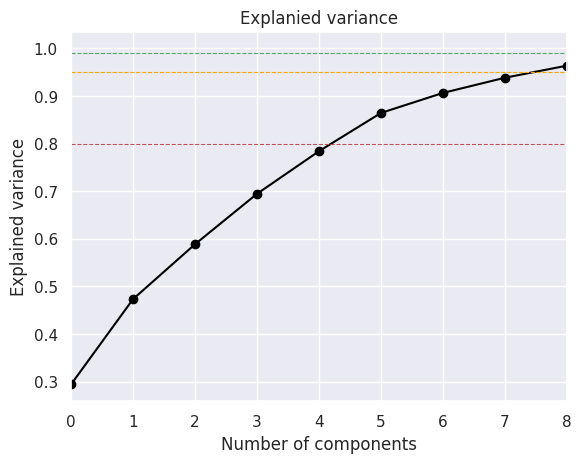

In [10]:
plt.figure()

plt.plot(pca.explained_variance_ratio_.cumsum(), marker = 'o', color='black')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.axhline(y=0.99, color='g', linestyle='--', linewidth=0.8, label='y = 0.99')
plt.axhline(y=0.95, color='orange', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.axhline(y=0.8, color='r', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.xlim(0, 8)
# Añadir un título (opcional)
plt.title('Explanied variance')

plt.savefig('/app/html/1-explained_variance.svg', format='svg')

# Mostrar el gráfico
plt.show()

In [11]:
pca = PCA(n_components = 3)

In [12]:
pca.fit(nuclei_cytoplasm_std)

PCA(n_components=3)

In [13]:
pca_result = pca.transform(nuclei_cytoplasm_std)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    title='PCA 3D Scatter Plot',
                    labels={'PC1': 'Principal Component 1',
                            'PC2': 'Principal Component 2',
                            'PC3': 'Principal Component 3'})

fig.write_html('/app/html/2-pca.html')

## K-Means

In [14]:
scores_pca = pca.transform(nuclei_cytoplasm_std)
scores_pca

array([[-1.91704965, -3.48490011,  4.43828598],
       [-0.34556451, -1.25748829,  5.82406002],
       [-1.73885005, -3.15230809,  4.74869913],
       ...,
       [ 3.46583435,  7.18053973, -0.51475446],
       [ 3.21353886,  7.62012887, -4.57128853],
       [ 7.54419105,  6.4372587 , -2.56489663]])

In [15]:
wcss = []
for i in range (1,21):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will chang

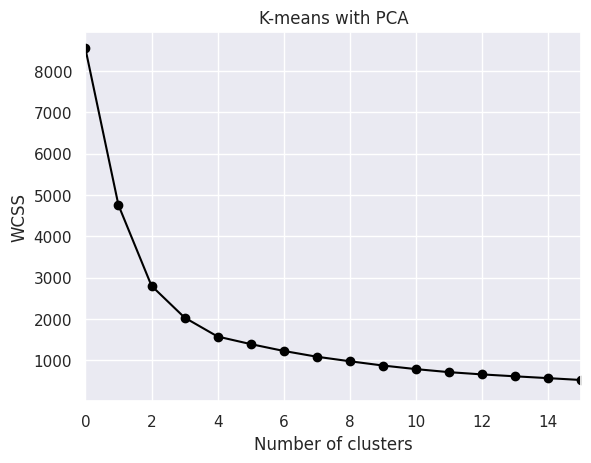

In [16]:
plt.figure()

plt.plot(wcss, marker = 'o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA')

plt.xlim(0, 15)

plt.savefig('/app/html/3-kmeans_pca.svg', format='svg')

plt.show()

In [17]:
kmeans_pca = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)

In [18]:
kmeans_pca.fit(scores_pca)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



KMeans(n_clusters=3, random_state=42)

In [19]:
df_segm_pca_kmeans = pd.concat([nuclei_cytoplasm.reset_index(drop = True), pd.DataFrame(scores_pca)], axis = 1)
df_segm_pca_kmeans.columns.values[-3: ] = ['C1', 'C2', 'C3']
df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_

In [20]:
df_segm_pca_kmeans['Segment'] = df_segm_pca_kmeans['Segment K-means PCA'].map({
    0:'Primero',
    1:'Segundo',
    2:'Tercero'})

In [21]:
df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3'
})

fig = px.scatter_3d(df_plotly, x='C1', y='C2', z='C3', color='Segment K-means PCA',
                    labels={'C1': 'Componente 1', 'C2': 'Componente 2', 'C3': 'Componente 3'},
                    title='PCA with K-Means Clustering')

fig.write_html('/app/html/4-pca_kmeans.html')


## UMap

In [22]:
n_neighbors =5
min_dist =1
n_components = 3
local_connectivity = 0.1
spread =1
random_state = 42

In [23]:
# Crear gráfico 3D si quieres explorar en 3 dimensiones (necesitas n_components=3)
umap_model_3d = umap.UMAP(n_neighbors=5, min_dist=min_dist, metric='euclidean', n_components=n_components, local_connectivity=local_connectivity, spread=spread, random_state=random_state)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)
df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])

fig_3d = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3',
                      labels={'UMAP1': 'UMAP Dimension 1', 'UMAP2': 'UMAP Dimension 2', 'UMAP3': 'UMAP Dimension 3'},
                      title='UMAP Projection of Original Data (3D)')

fig_3d.write_html('/app/html/5-umap_3d.html')

/usr/local/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



## K-means

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will chang

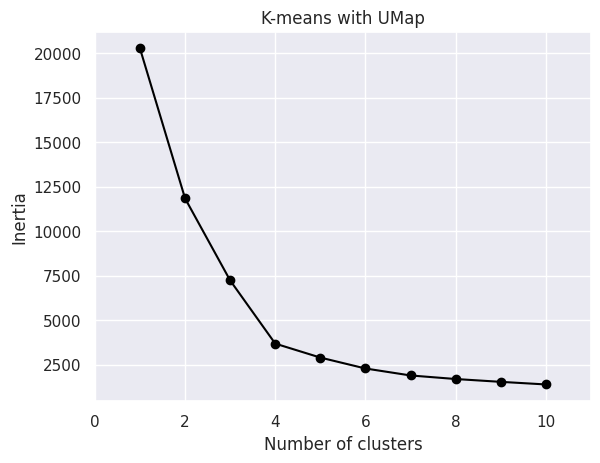

In [24]:
inertia = []
k_range = range(1, 11)  # Probar con 1 a 10 clústeres

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(umap_result_3d)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker = 'o', color='black')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('K-means with UMap')

plt.xlim(0, 11)

plt.savefig('/app/html/6-kmeans_umap.svg', format='svg')

plt.show()

In [25]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=3)  # Ajusta el número de clústeres según sea necesario
clusters = kmeans.fit_predict(umap_result_3d)

# Agregar las etiquetas de clúster al DataFrame
df_umap_3d['Cluster'] = clusters

fig = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3', color='Cluster',
                    title='UMAP with K-Means Clustering')
fig.write_html('/app/html/7-umap_kmeans.html')

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



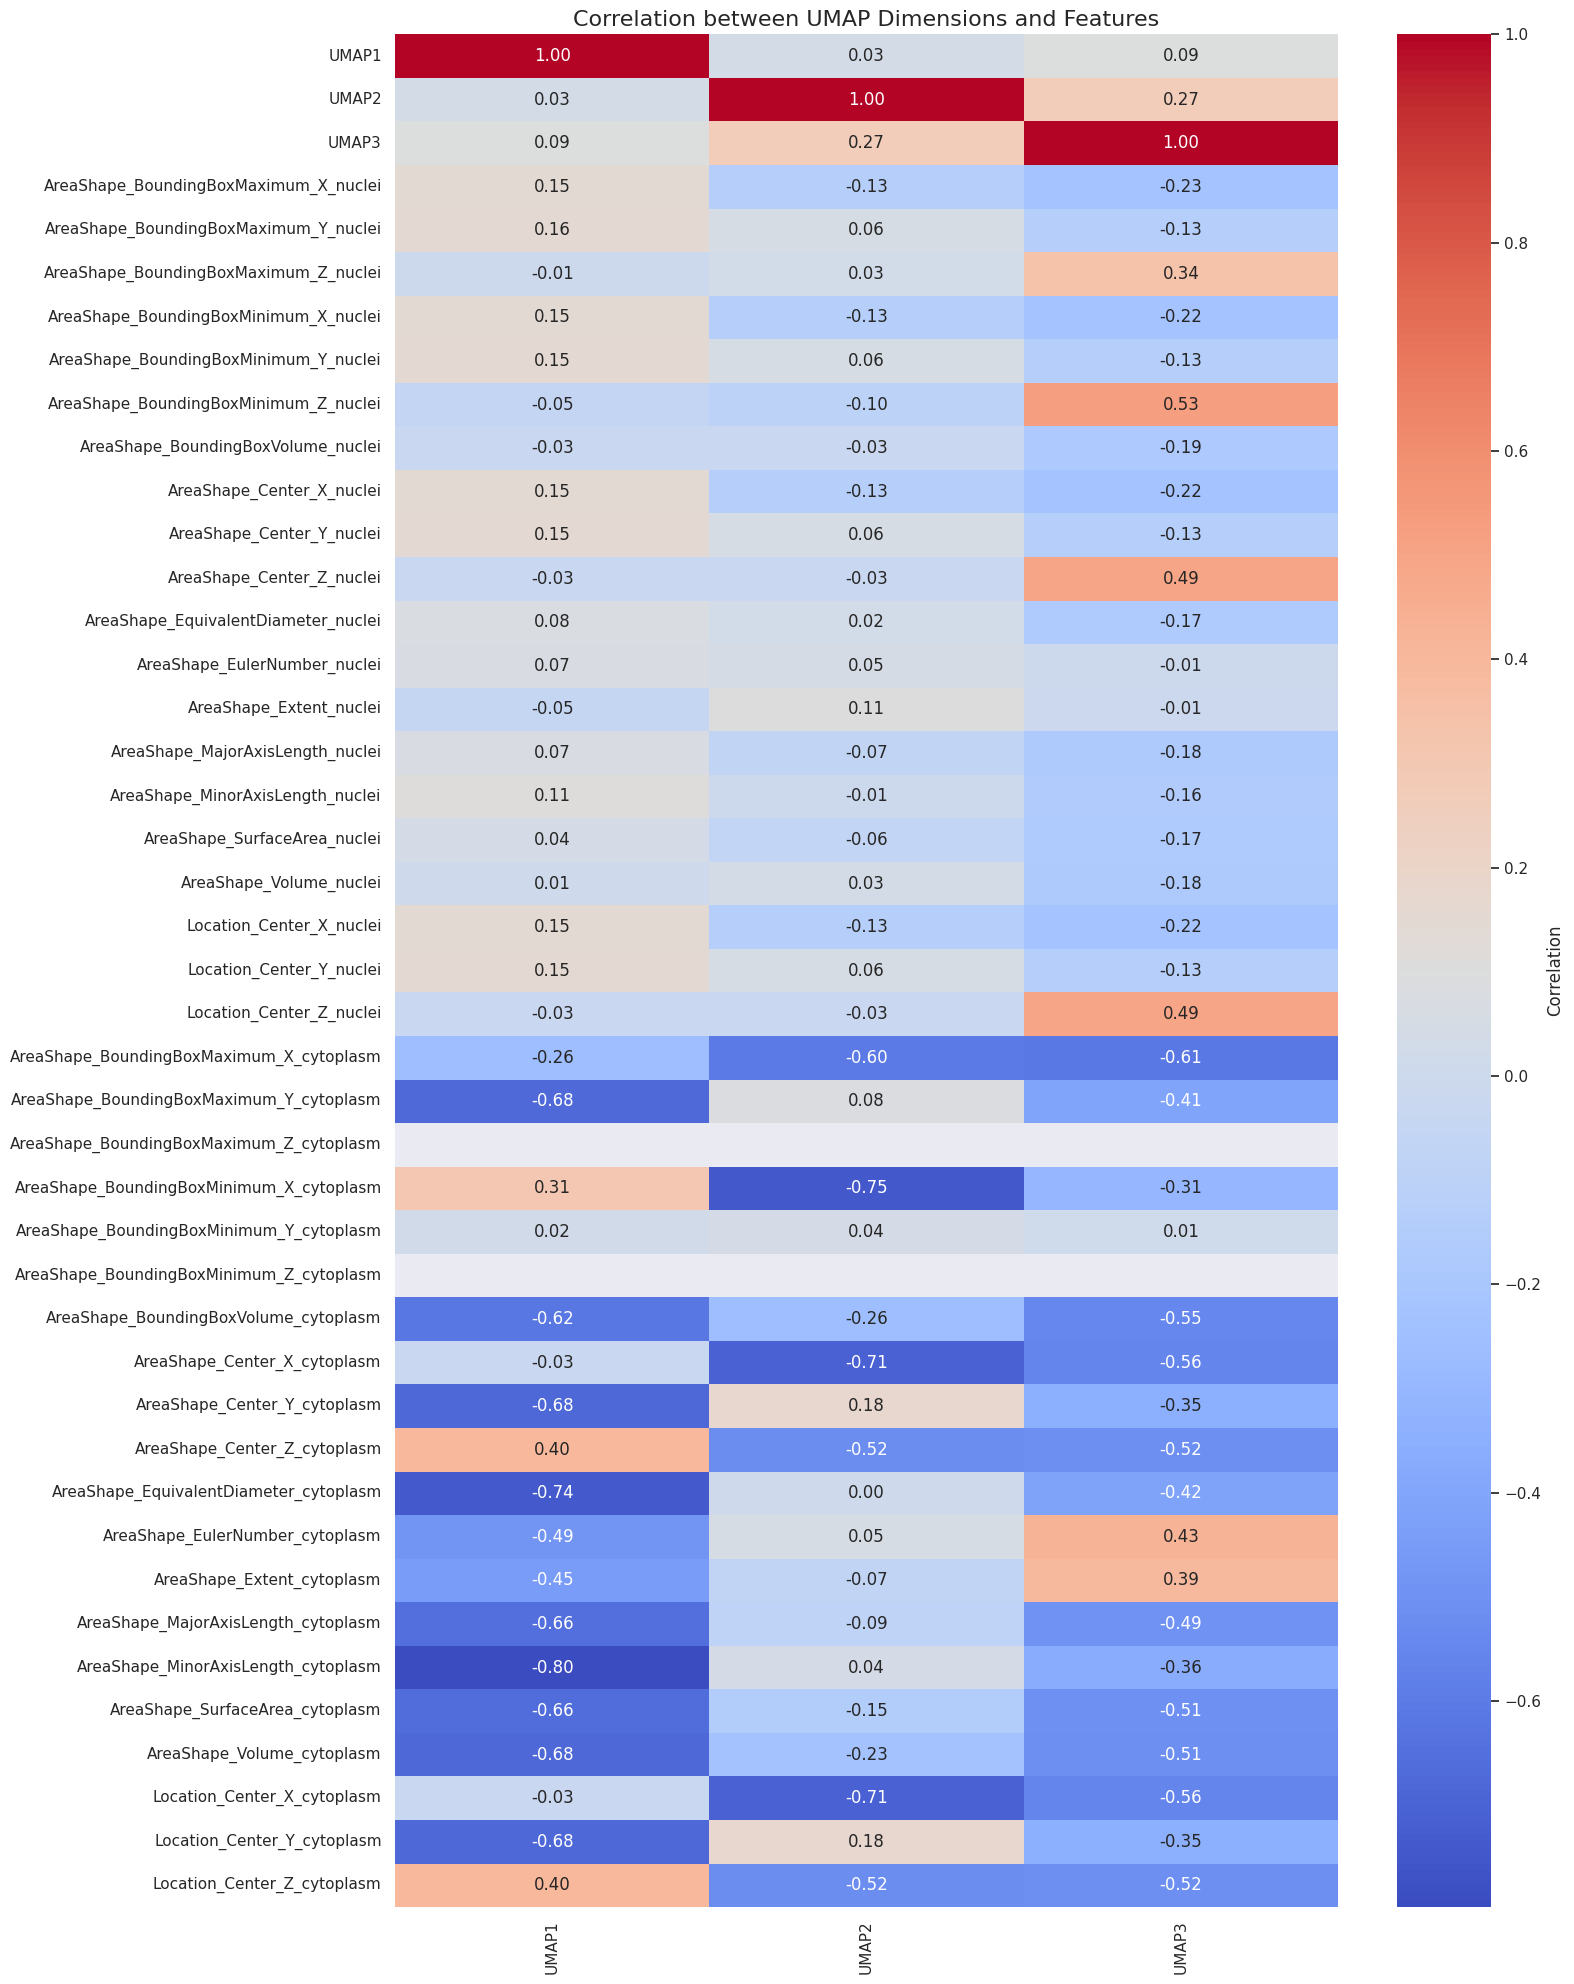

In [27]:
# Crear un DataFrame con las dimensiones UMAP
df_umap = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])

# Concatenar las características originales para calcular correlaciones
df_umap_features = pd.concat([df_umap, nuclei_cytoplasm.reset_index(drop=True)], axis=1)

# Calcular la matriz de correlación entre las dimensiones UMAP y las características originales
corr_matrix = df_umap_features.corr().loc['UMAP1':'UMAP3', :]

# Transponer la matriz de correlación para girar el heatmap 90 grados
corr_matrix_transposed = corr_matrix.T

# Crear el heatmap de correlación girado con un tamaño más largo
plt.figure(figsize=(16, 20))  # Ajusta el tamaño (ancho x alto) para hacerlo más largo
sns.heatmap(corr_matrix_transposed, cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.title('Correlation between UMAP Dimensions and Features', fontsize=16)
plt.xticks(rotation=90)  # Rota las etiquetas del eje X si es necesario
plt.yticks(rotation=0)  # Mantiene las etiquetas del eje Y en orientación normal
plt.tight_layout()  # Ajusta el layout para que no haya recortes
plt.savefig('/app/html/8-umap_correlation_heatmap.svg', format='svg')
plt.show()